In [77]:
import pandas as pd
import  numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import datetime as dt
from datetime import datetime


## EDA

In [78]:
df= pd.read_csv("data.csv")
display(df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,"2,55",17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,"2,75",17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,"0,85",12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,"2,1",12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,"4,15",12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,"4,15",12680.0,France


In [79]:
df.info


<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

          InvoiceDate UnitPrice  CustomerID

In [80]:
df.shape

(541909, 8)

In [81]:
df.head(5)
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [82]:

df.dtypes
df.head(4)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,"2,55",17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,"2,75",17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,"3,39",17850.0,United Kingdom


In [83]:
df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

          InvoiceDate UnitPrice  Customer

### data preparing

In [84]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### convert InvocieNo to float

### traiter  les donness manquantes

In [85]:
df.dropna(subset=['CustomerID'],inplace=True)
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Analyse CostumerID 

In [86]:
df['CustomerID'].head()
df['CustomerID'].dtype

df['CustomerID'].isna().sum()

df['CustomerID'].nunique()


4372

In [87]:
df['CustomerID'].value_counts().describe()     

count    4372.000000
mean       93.053294
std       232.471608
min         1.000000
25%        17.000000
50%        42.000000
75%       102.000000
max      7983.000000
Name: count, dtype: float64

In [88]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df.dtypes

C:\Users\Youcode\AppData\Local\Temp\ipykernel_11812\2208571527.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])


InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice                 str
CustomerID            float64
Country                   str
dtype: object

## traiter les donnees  

In [89]:
df_uniq=df['CustomerID'].isna().sum()
print(df_uniq)
df
df['UnitPrice']=df['UnitPrice'].str.replace(',','.').astype(float)

0


<Axes: xlabel='Country'>

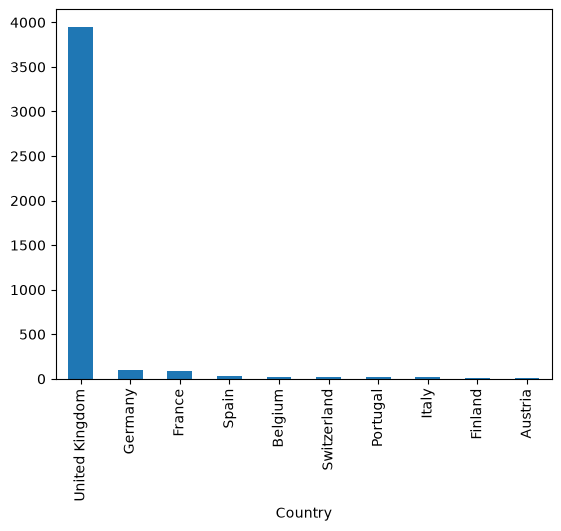

In [90]:
filtered_data=df[['Country','CustomerID']].drop_duplicates()


filtered_data.Country.value_counts()[:10].plot(kind='bar')

### RFM

In [91]:
df_rfm = df.copy()
df_rfm = df_rfm[df_rfm['Quantity'] > 0]
df_rfm = df_rfm[df_rfm['UnitPrice'] > 0]

print(df_rfm.shape)
df_rfm.head()

(397884, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Frequency

In [92]:
freq = df_rfm.groupby('CustomerID')['InvoiceNo'].nunique().rename('Frequence')
freq.head()

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: Frequence, dtype: int64

### Recency

In [93]:
from datetime import datetime

now = datetime.now()

last_sales = df_rfm.groupby('CustomerID')['InvoiceDate'].max()

def recency(time):
    return (now - time).days

recence = last_sales.apply(recency).rename('Recence')
recence.head()

CustomerID
12346.0    5732
12347.0    5409
12348.0    5482
12349.0    5425
12350.0    5717
Name: Recence, dtype: int64

40


,Description,Quantity,UnitPrice
9302,ROUND CAKE TIN VINTAGE GREEN,1,0.0
33576,ADVENT CALENDAR GINGHAM SACK,4,0.0
40089,REGENCY CAKESTAND 3 TIER,10,0.0
47068,PAPER BUNTING RETROSPOT,24,0.0
47070,PLASTERS IN TIN SKULLS,24,0.0
56674,ORGANISER WOOD ANTIQUE WHITE,1,0.0
86789,FAIRY CAKES NOTEBOOK A6 SIZE,16,0.0
130188,CERAMIC BOWL WITH LOVE HEART DESIGN,36,0.0
139453,MINI CAKE STAND HANGING STRAWBERY,5,0.0
145208,HEART GARLAND RUSTIC PADDED,2,0.0


### Monetary

In [96]:
df_rfm['Total_Price'] = df_rfm['Quantity'] * df_rfm['UnitPrice']

montant = df_rfm.groupby('CustomerID')['Total_Price'].sum().rename('Montant')
montant.head()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: Montant, dtype: float64